# Cross-venue prediction market spreads: gross vs. executable

This notebook analyzes **real sample data** (2026-08-19) from the
[Prediction Spread Scanner](https://apify.com/nanare-sudo/prediction-spread-scanner?utm_source=github&utm_medium=organic&utm_campaign=pmdata_repo&utm_content=notebook):
verified Kalshi × Polymarket market pairs with orderbook-aware executable spreads.

The point this data makes: **a price difference is not an arbitrage.** Once you walk the
orderbook at a realistic order size and apply Kalshi's fee (`0.07·p·(1−p)` per contract),
a large share of observed spreads shrinks or goes negative.

Fresh data: run the Actor (`mode: "scan"`) — see `examples/spread_scan.py`.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

spreads = pd.json_normalize(json.load(open("../data/sample_spreads.json")))
matches = pd.read_csv("../data/sample_matches.csv")
spreads[["kalshi.title", "match_confidence", "gross_spread_midpoint",
         "executable_spread_100", "executable_spread_1000", "depth_limited"]]

,kalshi.title,match_confidence,gross_spread_midpoint,executable_spread_100,executable_spread_1000,depth_limited
0,Will Alexandria Ocasio-Cortez be the Democrati...,0.841,0.0220,0.0057,0.0006,False
1,Will Chris Murphy be the Democratic Presidenti...,0.837,0.0035,0.0006,-0.0001,False
2,Will Wes Moore be the Democratic Presidential ...,0.837,0.0060,-0.0004,-0.0094,False
3,Will Mark Cuban be the Democratic Presidential...,0.837,0.0010,-0.0013,-0.0058,False
4,Will Jon Stewart be the Democratic Presidentia...,0.837,0.0015,-0.0005,-0.0077,False


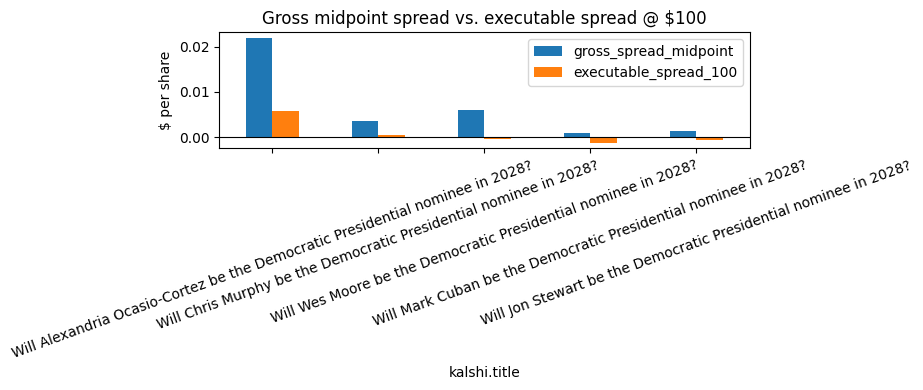

In [2]:
ax = spreads.plot.bar(
    x="kalshi.title", y=["gross_spread_midpoint", "executable_spread_100"],
    figsize=(9, 4), rot=20, title="Gross midpoint spread vs. executable spread @ $100")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("$ per share")
plt.tight_layout()

In [3]:
neg = (spreads["executable_spread_100"] < 0).mean()
print(f"pairs with NEGATIVE executable spread @$100: {neg:.0%}")
print(f"median gross spread:      ${spreads['gross_spread_midpoint'].median():.4f}")
print(f"median executable @$100:  ${spreads['executable_spread_100'].median():.4f}")
print(f"median match confidence:  {matches['match_confidence'].median():.2f}")

pairs with NEGATIVE executable spread @$100: 60%
median gross spread:      $0.0035
median executable @$100:  $-0.0004
median match confidence:  0.84


## Takeaways

- The **gross** spread (midpoint difference) systematically overstates what is capturable.
- `depth_limited` pairs cannot even absorb a $100 order on one side.
- Matching quality matters more than spread size: a "spread" between two *non-equivalent*
  contracts is just a category error — that's why every pair carries `match_confidence`
  and `resolution_diff_notes`.

Methodology and limitations: [`docs/methodology.md`](../docs/methodology.md).
*Market data for research — not trading advice, no profit claims.*